# 🌌 Galaxies — Segmentação de Consumidores via Clustering

**Objetivo**: Segmentar consumidores através de análise de clusters, extraindo insights práticos para a equipe de negócios.

**Etapas**:
1. Carregamento e Exploração dos Dados
2. Tratamento de Dados Categóricos
3. Feature Engineering
4. Gráficos e Visualizações
5. Redução de Dimensionalidade
6. Clustering (KMeans + GMM)
7. Perfilamento dos Clusters
8. Exportação do Perfil para o Sistema de Agentes

---

## 0. Instalação e Imports

In [1]:
# Instalar dependências (Google Colab)
!pip install umap-learn -q

In [2]:
"""Imports principais para o pipeline de clustering."""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from datetime import datetime
from pathlib import Path

# Scikit-learn
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

# Seed para reprodutibilidade
RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

print('✅ Imports carregados com sucesso.')

✅ Imports carregados com sucesso.


---
## 1. Carregamento e Exploração Inicial dos Dados

Nesta etapa carregamos o dataset sintético e fazemos uma exploração inicial para entender:
- Formato e tipos de dados
- Quantidade de valores nulos/vazios
- Estatísticas descritivas
- Pontos de atenção identificados no enunciado

In [3]:
"""Carregar dados sintéticos.

Ajuste o caminho conforme o ambiente:
- Google Colab: fazer upload ou montar Google Drive
- Local: usar caminho relativo
"""

# Para Google Colab, descomente as linhas abaixo:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/Othercomputers/Meu laptop/Projects/Galaxies/data/dados_sinteticos.csv'

# Para execução local:
# DATA_PATH: str = '../data/dados_sinteticos.csv'

df: pd.DataFrame = pd.read_csv(DATA_PATH)

print(f'📊 Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'📋 Colunas: {list(df.columns)}')
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Dataset carregado: 3000 linhas × 11 colunas
📋 Colunas: ['canal_preferido', 'categoria_favorita', 'regiao', 'marca_preferida', 'influenciador', 'frequencia_compra', 'pagamento', 'genero', 'ticket_medio', 'qtd_itens', 'data_nascimento']


,canal_preferido,categoria_favorita,regiao,marca_preferida,influenciador,frequencia_compra,pagamento,genero,ticket_medio,qtd_itens,data_nascimento
0,whatsapp,mercearia,nordeste,marca_52,influencer_062,quinzenal,credito,feminino,111.866313,3,12/09/1969
1,parceiros,limpeza,sudeste,marca_14,influencer_042,semanal,boleto,nao_informado,128.156105,6,13/01/1996
2,app,snacks,nordeste,marca_29,influencer_008,quinzenal,carteira_digital,outro,90.987727,6,22/08/1993
3,whatsapp,mercearia,sudeste,marca_01,influencer_118,bimestral,debito,outro,136.000269,3,22/06/1976
4,loja_fisica,bebidas,sudeste,marca_00,influencer_020,mensal,carteira_digital,nao_informado,144.617137,2,16/02/2007
5,app,mercearia,nordeste,marca_42,influencer_030,semanal,boleto,masculino,141.713922,9,26/04/1981
6,whatsapp,limpeza,norte,marca_06,influencer_028,quinzenal,carteira_digital,masculino,113.956669,7,17/01/1955
7,whatsapp,bebidas,centro_oeste,marca_32,influencer_108,trimestral,debito,outro,163.636452,4,25/02/2006
8,loja_fisica,bebidas,norte,marca_41,influencer_091,mensal,credito,nao_informado,109.695302,2,13/10/1956
9,parceiros,mercearia,centro_oeste,marca_01,influencer_054,mensal,credito,nao_informado,106.047168,2,07/11/2003


In [4]:
"""Informações gerais do dataset: tipos, nulos, memória."""

print('=== INFO DO DATASET ===')
print(f'Shape: {df.shape}')
print(f'\nMemória: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'\n--- Tipos de dados ---')
print(df.dtypes)
print(f'\n--- Valores nulos por coluna ---')
nulos: pd.Series = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Nenhum valor nulo encontrado ✅')
print(f'\n--- Valores vazios (strings) por coluna ---')
vazios: pd.Series = (df == '').sum()
print(vazios[vazios > 0] if vazios.sum() > 0 else 'Nenhum valor vazio encontrado ✅')

=== INFO DO DATASET ===
Shape: (3000, 11)

Memória: 1571.2 KB

--- Tipos de dados ---
canal_preferido        object
categoria_favorita     object
regiao                 object
marca_preferida        object
influenciador          object
frequencia_compra      object
pagamento              object
genero                 object
ticket_medio          float64
qtd_itens               int64
data_nascimento        object
dtype: object

--- Valores nulos por coluna ---
Nenhum valor nulo encontrado ✅

--- Valores vazios (strings) por coluna ---
Nenhum valor vazio encontrado ✅


In [5]:
"""Estatísticas descritivas para variáveis numéricas."""

print('=== ESTATÍSTICAS DESCRITIVAS (Numéricas) ===')
df.describe()

=== ESTATÍSTICAS DESCRITIVAS (Numéricas) ===


,ticket_medio,qtd_itens
count,3000.000000,3000.000000
mean,121.818805,4.028000
std,39.999201,1.988433
min,10.000000,0.000000
25%,94.951767,3.000000
50%,122.204219,4.000000
75%,147.962583,5.000000
max,253.098891,12.000000


In [6]:
"""Estatísticas descritivas para variáveis categóricas."""

print('=== ESTATÍSTICAS DESCRITIVAS (Categóricas) ===')
df.describe(include='object')

=== ESTATÍSTICAS DESCRITIVAS (Categóricas) ===


,canal_preferido,categoria_favorita,regiao,marca_preferida,influenciador,frequencia_compra,pagamento,genero,data_nascimento
count,3000,3000,3000,3000,3000,3000,3000,3000,3000
unique,5,6,5,60,120,5,5,4,2766
top,loja_fisica,bebidas,sudeste,marca_29,influencer_078,semanal,credito,masculino,18/01/2007
freq,730,625,700,63,38,719,700,873,3


In [7]:
"""Verificar distribuição de valores únicos por coluna categórica.

Pontos de atenção:
- marca_preferida: 60 categorias (alta cardinalidade)
- influenciador: 120 categorias (alta cardinalidade)
- genero: 4 categorias (masculino, feminino, outro, nao_informado)
- qtd_itens: verificar zeros
"""

colunas_categoricas: list[str] = df.select_dtypes(include='object').columns.tolist()

for col in colunas_categoricas:
    n_unique: int = df[col].nunique()
    print(f'\n📌 {col} ({n_unique} categorias):')
    if n_unique <= 10:
        print(df[col].value_counts())
    else:
        print(f'   Top 5: {df[col].value_counts().head().to_dict()}')
        print(f'   Bottom 5: {df[col].value_counts().tail().to_dict()}')


📌 canal_preferido (5 categorias):
canal_preferido
loja_fisica    730
parceiros      588
app            584
ecommerce      553
whatsapp       545
Name: count, dtype: int64

📌 categoria_favorita (6 categorias):
categoria_favorita
bebidas       625
snacks        519
limpeza       478
mercearia     471
higiene       461
laticinios    446
Name: count, dtype: int64

📌 regiao (5 categorias):
regiao
sudeste         700
sul             596
norte           579
centro_oeste    563
nordeste        562
Name: count, dtype: int64

📌 marca_preferida (60 categorias):
   Top 5: {'marca_29': 63, 'marca_00': 63, 'marca_10': 63, 'marca_14': 61, 'marca_13': 60}
   Bottom 5: {'marca_52': 39, 'marca_26': 38, 'marca_32': 37, 'marca_54': 37, 'marca_16': 35}

📌 influenciador (120 categorias):
   Top 5: {'influencer_078': 38, 'influencer_073': 38, 'influencer_093': 38, 'influencer_066': 36, 'influencer_017': 36}
   Bottom 5: {'influencer_030': 16, 'influencer_034': 16, 'influencer_070': 15, 'influencer_065': 14,

In [8]:
"""Verificar valores zero em campos numéricos.

Ponto de atenção do enunciado: valores 0 ou 0.0 em campos numéricos.
"""

print('=== ZEROS EM CAMPOS NUMÉRICOS ===')
for col in ['ticket_medio', 'qtd_itens']:
    qtd_zeros: int = (df[col] == 0).sum()
    pct_zeros: float = qtd_zeros / len(df) * 100
    print(f'{col}: {qtd_zeros} zeros ({pct_zeros:.2f}%)')

=== ZEROS EM CAMPOS NUMÉRICOS ===
ticket_medio: 0 zeros (0.00%)
qtd_itens: 56 zeros (1.87%)


In [9]:
"""Correção: qtd_itens == 0 com ticket_medio != 0 → qtd_itens = 1.

Regra de negócio: não faz sentido ter compra com valor mas zero itens.
"""

mascara_correcao = (df['qtd_itens'] == 0) & (df['ticket_medio'] != 0)
n_corrigidos = mascara_correcao.sum()

print(f'Registros com qtd_itens=0 e ticket>0: {n_corrigidos}')
df.loc[mascara_correcao, 'qtd_itens'] = 1
print(f'✅ {n_corrigidos} registros corrigidos → qtd_itens = 1')

# Verificação
print(f'\nApós correção:')
print(f'  qtd_itens == 0: {(df["qtd_itens"] == 0).sum()} restantes')


Registros com qtd_itens=0 e ticket>0: 56
✅ 56 registros corrigidos → qtd_itens = 1

Após correção:
  qtd_itens == 0: 0 restantes


---
## 2. Tratamento de Dados Categóricos

Estratégias por coluna:

| Coluna | Estratégia | Justificativa |
|--------|-----------|---------------|
| `canal_preferido` | One-Hot Encoding | Baixa cardinalidade (5), sem ordem |
| `categoria_favorita` | One-Hot Encoding | Baixa cardinalidade (6), sem ordem |
| `regiao` | One-Hot Encoding | Baixa cardinalidade (5), sem ordem |
| `frequencia_compra` | Ordinal Encoding | Tem ordem natural (semanal > quinzenal > ... > trimestral) |
| `pagamento` | One-Hot Encoding | Baixa cardinalidade (5), sem ordem |
| `genero` | One-Hot Encoding | Baixa cardinalidade (4), sem ordem |
| `marca_preferida` | Frequency Encoding | Alta cardinalidade (60), sem ordem |
| `influenciador` | **Remover** | Alta cardinalidade (120), muito ruído para clustering |
| `data_nascimento` | Transformar em `idade` | Dado temporal → numérico |

In [10]:
"""Criar cópia do dataframe para processamento."""

df_proc: pd.DataFrame = df.copy()

# --- 1. Converter data_nascimento para idade ---
# Formato: DD/MM/YYYY
df_proc['data_nascimento'] = pd.to_datetime(
    df_proc['data_nascimento'], format='%d/%m/%Y', errors='coerce'
)

data_referencia: datetime = datetime(2026, 5, 25)  # Data de referência do projeto
df_proc['idade'] = ((data_referencia - df_proc['data_nascimento']).dt.days / 365.25).astype(int)

print(f'Idade — Min: {df_proc["idade"].min()}, Max: {df_proc["idade"].max()}, '
      f'Média: {df_proc["idade"].mean():.1f}')

# Remover coluna original
df_proc.drop(columns=['data_nascimento'], inplace=True)

print('✅ data_nascimento → idade')

Idade — Min: 18, Max: 71, Média: 44.6
✅ data_nascimento → idade


In [11]:
"""Criar faixas etárias com intervalos por geração - Gen Z, Millennials, Gen X, Boomers """

bins: list[int] = [0, 18, 25, 40, 55, 70, 120]
labels: list[str] = [
    '<18', '18-25', '25-40', '40-55', '55-70', '70+'
]

df_proc['faixa_etaria'] = pd.cut(
    df_proc['idade'], bins=bins, labels=labels, right=False
)

print('Distribuição por faixa etária:')
print(df_proc['faixa_etaria'].value_counts().sort_index())

Distribuição por faixa etária:
faixa_etaria
<18        0
18-25    380
25-40    832
40-55    826
55-70    895
70+       67
Name: count, dtype: int64


In [12]:
"""Codificação ordinal para frequencia_compra.

Ordem: trimestral(1) < bimestral(2) < mensal(3) < quinzenal(4) < semanal(5)
Quanto maior o valor, maior a frequência de compra.
"""

ORDEM_FREQUENCIA: dict[str, int] = {
    'trimestral': 1,
    'bimestral': 2,
    'mensal': 3,
    'quinzenal': 4,
    'semanal': 5
}

df_proc['frequencia_ordinal'] = df_proc['frequencia_compra'].map(ORDEM_FREQUENCIA)

print('Mapeamento de frequência:')
print(df_proc[['frequencia_compra', 'frequencia_ordinal']].drop_duplicates().sort_values('frequencia_ordinal'))

print('\n✅ frequencia_compra → frequencia_ordinal')

Mapeamento de frequência:
  frequencia_compra  frequencia_ordinal
7        trimestral                   1
3         bimestral                   2
4            mensal                   3
0         quinzenal                   4
1           semanal                   5

✅ frequencia_compra → frequencia_ordinal


In [13]:
"""Frequency Encoding para marca_preferida.

Substitui cada categoria pela sua frequência relativa no dataset.
Justificativa: com 60 categorias, One-Hot geraria dimensionalidade
excessiva. Frequency encoding captura a popularidade da marca.
"""

freq_marca: pd.Series = df_proc['marca_preferida'].value_counts(normalize=True)
df_proc['marca_freq'] = df_proc['marca_preferida'].map(freq_marca)

print(f'marca_freq — Min: {df_proc["marca_freq"].min():.4f}, '
      f'Max: {df_proc["marca_freq"].max():.4f}')
print('\n✅ marca_preferida → marca_freq (frequency encoding)')

marca_freq — Min: 0.0117, Max: 0.0210

✅ marca_preferida → marca_freq (frequency encoding)


In [14]:
"""Remover colunas que não serão usadas no clustering.

- influenciador: 120 categorias, muito ruído
- frequencia_compra: substituída por frequencia_ordinal
- marca_preferida: substituída por marca_freq

- idade x faixa_etaria: Testar ambas --> Faixa etária de 5 em 5 ficou ruim
"""

# colunas_remover: list[str] = ['influenciador', 'frequencia_compra', 'marca_preferida', 'faixa_etaria', 'marca_freq']
colunas_remover: list[str] = ['influenciador', 'frequencia_compra', 'marca_preferida', 'idade', 'marca_freq']
df_proc.drop(columns=colunas_remover, inplace=True)

print(f'Colunas removidas: {colunas_remover}')
print(f'Colunas restantes: {list(df_proc.columns)}')

Colunas removidas: ['influenciador', 'frequencia_compra', 'marca_preferida', 'idade', 'marca_freq']
Colunas restantes: ['canal_preferido', 'categoria_favorita', 'regiao', 'pagamento', 'genero', 'ticket_medio', 'qtd_itens', 'faixa_etaria', 'frequencia_ordinal']


In [15]:
"""One-Hot Encoding para categóricas de baixa cardinalidade.

Colunas: canal_preferido, categoria_favorita, regiao, pagamento, genero
"""

# colunas_onehot: list[str] = ['canal_preferido', 'categoria_favorita', 'regiao', 'pagamento', 'genero']
colunas_onehot: list[str] = ['canal_preferido', 'categoria_favorita', 'regiao', 'pagamento', 'genero', 'faixa_etaria']

df_encoded: pd.DataFrame = pd.get_dummies(
    df_proc,
    columns=colunas_onehot,
    drop_first=False,  # Manter todas as categorias para interpretação
    dtype=int
)

print(f'Shape antes do encoding: {df_proc.shape}')
print(f'Shape depois do encoding: {df_encoded.shape}')
print(f'\nColunas finais ({df_encoded.shape[1]}):')
for i, col in enumerate(df_encoded.columns):
    print(f'  {i+1}. {col}')

Shape antes do encoding: (3000, 9)
Shape depois do encoding: (3000, 34)

Colunas finais (34):
  1. ticket_medio
  2. qtd_itens
  3. frequencia_ordinal
  4. canal_preferido_app
  5. canal_preferido_ecommerce
  6. canal_preferido_loja_fisica
  7. canal_preferido_parceiros
  8. canal_preferido_whatsapp
  9. categoria_favorita_bebidas
  10. categoria_favorita_higiene
  11. categoria_favorita_laticinios
  12. categoria_favorita_limpeza
  13. categoria_favorita_mercearia
  14. categoria_favorita_snacks
  15. regiao_centro_oeste
  16. regiao_nordeste
  17. regiao_norte
  18. regiao_sudeste
  19. regiao_sul
  20. pagamento_boleto
  21. pagamento_carteira_digital
  22. pagamento_credito
  23. pagamento_debito
  24. pagamento_pix
  25. genero_feminino
  26. genero_masculino
  27. genero_nao_informado
  28. genero_outro
  29. faixa_etaria_<18
  30. faixa_etaria_18-25
  31. faixa_etaria_25-40
  32. faixa_etaria_40-55
  33. faixa_etaria_55-70
  34. faixa_etaria_70+


---
## 3. Feature Engineering

Nesta etapa montamos a **matriz de features** final para o clustering:
- Padronizar variáveis numéricas (StandardScaler)
- Variáveis binárias do One-Hot já estão na escala [0, 1]

In [16]:
"""Padronizar variáveis numéricas com StandardScaler.

Variáveis numéricas: ticket_medio, qtd_itens, idade, frequencia_ordinal, marca_freq
Padronização z-score: (x - mean) / std → média 0, desvio 1.
Necessário para KMeans (baseado em distância euclidiana).
"""

# colunas_numericas: list[str] = ['ticket_medio', 'qtd_itens', 'frequencia_ordinal', 'marca_freq', 'idade']
colunas_numericas: list[str] = ['ticket_medio', 'qtd_itens', 'frequencia_ordinal']

scaler: StandardScaler = StandardScaler()
df_encoded[colunas_numericas] = scaler.fit_transform(df_encoded[colunas_numericas])

print('✅ Variáveis numéricas padronizadas (z-score)')
print(f'\nVerificação (média ≈ 0, std ≈ 1):')
print(df_encoded[colunas_numericas].describe().loc[['mean', 'std']].round(4))

✅ Variáveis numéricas padronizadas (z-score)

Verificação (média ≈ 0, std ≈ 1):
      ticket_medio  qtd_itens  frequencia_ordinal
mean       -0.0000    -0.0000             -0.0000
std         1.0002     1.0002              1.0002


In [17]:
"""Montar matriz de features final para clustering."""

X: np.ndarray = df_encoded.values

print(f'\n📐 Matriz de features: {X.shape[0]} amostras × {X.shape[1]} features')
print(f'Nenhum NaN: {not np.isnan(X).any()} ✅' if not np.isnan(X).any() else '⚠️ Existem NaN!')


📐 Matriz de features: 3000 amostras × 34 features
Nenhum NaN: True ✅


---
## 4. Gráficos e Visualizações

Visualizações exploratórias dos dados originais para entender distribuições e padrões.

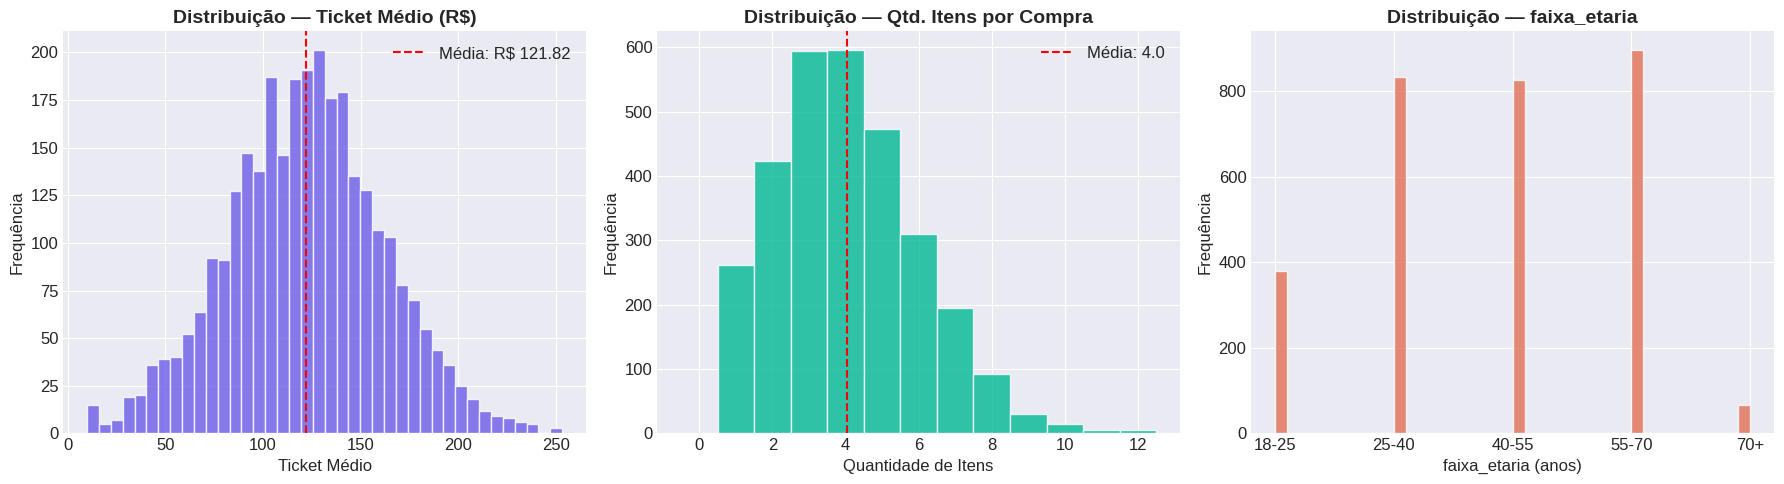

In [18]:
"""Distribuição das variáveis numéricas originais."""

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ticket Médio
axes[0].hist(df['ticket_medio'], bins=40, color='#6c5ce7', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribuição — Ticket Médio (R$)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ticket Médio')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['ticket_medio'].mean(), color='red', linestyle='--', label=f'Média: R$ {df["ticket_medio"].mean():.2f}')
axes[0].legend()

# Quantidade de Itens
axes[1].hist(df['qtd_itens'], bins=range(0, 14), color='#00b894', edgecolor='white', alpha=0.8, align='left')
axes[1].set_title('Distribuição — Qtd. Itens por Compra', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Quantidade de Itens')
axes[1].set_ylabel('Frequência')
axes[1].axvline(df['qtd_itens'].mean(), color='red', linestyle='--', label=f'Média: {df["qtd_itens"].mean():.1f}')
axes[1].legend()

# Idade (derivada)
# axes[2].hist(df_proc['idade'] * scaler.scale_[2] + scaler.mean_[2] if 'idade' in colunas_numericas else df_proc['idade'],
#              bins=40, color='#e17055', edgecolor='white', alpha=0.8)
# axes[2].set_title('Distribuição — Idade', fontsize=14, fontweight='bold')
# axes[2].set_xlabel('Idade (anos)')
# axes[2].set_ylabel('Frequência')
# axes[2].tick_params(axis='x', rotation=45)

axes[2].hist(df_proc.sort_values(by='faixa_etaria')['faixa_etaria'],
             bins=20, color='#e17055', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribuição — faixa_etaria', fontsize=14, fontweight='bold')
axes[2].set_xlabel('faixa_etaria (anos)')
axes[2].set_ylabel('Frequência')
# axes[2].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

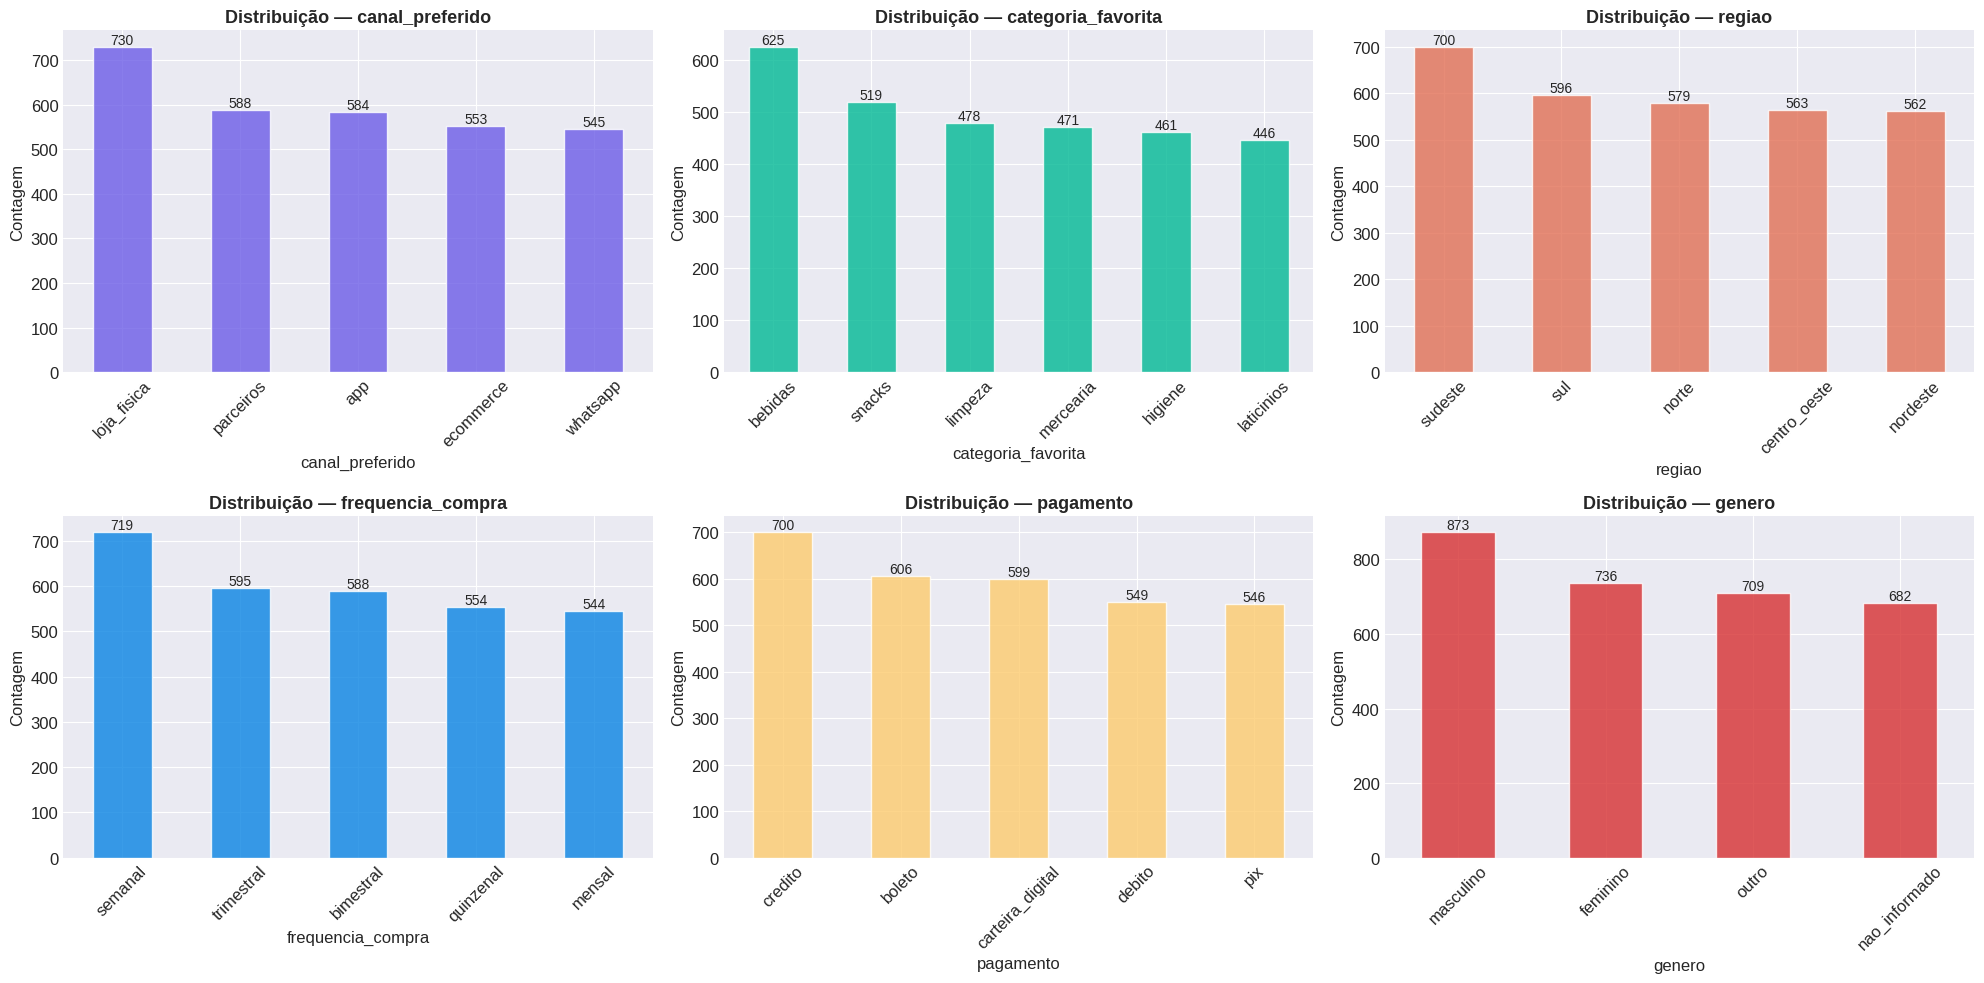

In [19]:
"""Gráficos de barras para variáveis categóricas de baixa cardinalidade."""

categoricas_plot: list[str] = [
    'canal_preferido', 'categoria_favorita', 'regiao',
    'frequencia_compra', 'pagamento', 'genero'
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
cores: list[str] = ['#6c5ce7', '#00b894', '#e17055', '#0984e3', '#fdcb6e', '#d63031']

for idx, (col, cor) in enumerate(zip(categoricas_plot, cores)):
    ax = axes[idx // 3][idx % 3]
    contagem: pd.Series = df[col].value_counts()
    contagem.plot(kind='bar', ax=ax, color=cor, edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribuição — {col}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Contagem')
    ax.tick_params(axis='x', rotation=45)

    # Adicionar valores nas barras
    for bar_item in ax.patches:
        ax.annotate(
            f'{int(bar_item.get_height())}',
            (bar_item.get_x() + bar_item.get_width() / 2, bar_item.get_height()),
            ha='center', va='bottom', fontsize=10
        )

plt.tight_layout()
plt.show()

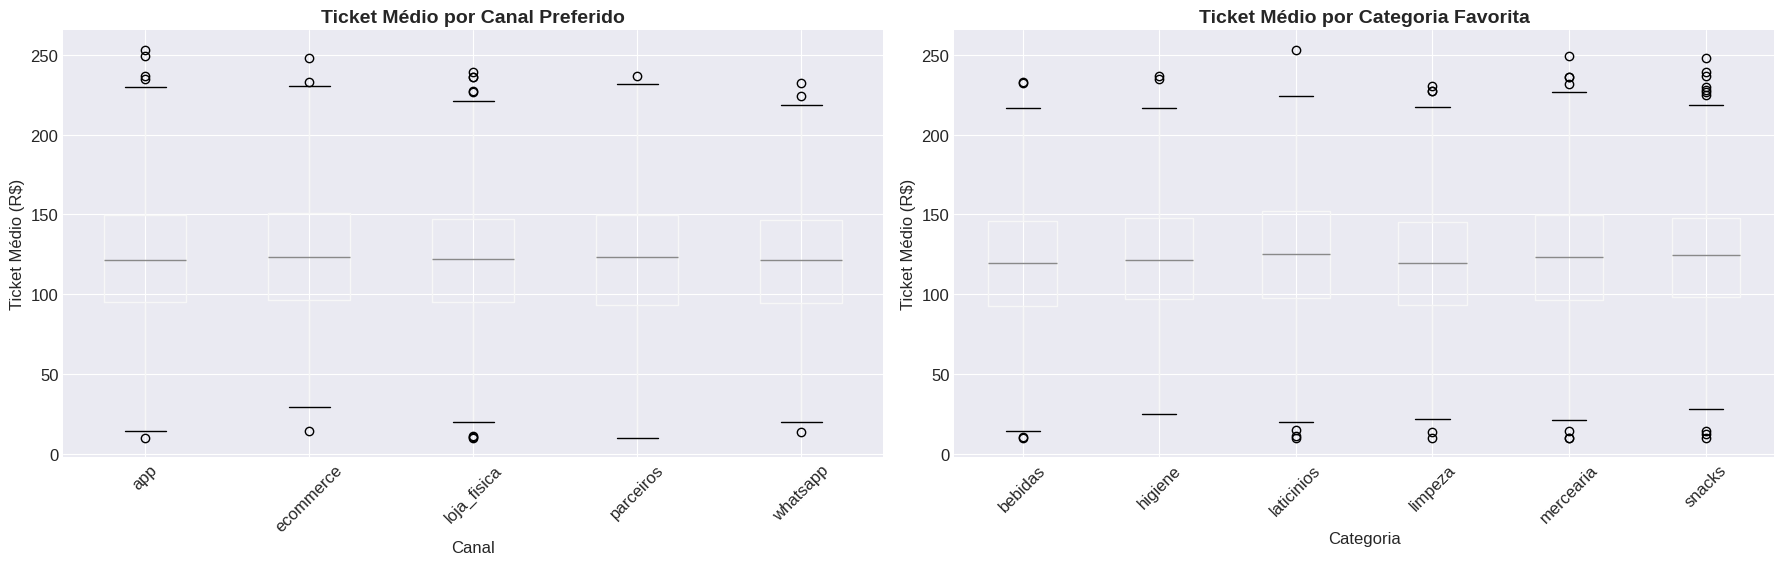

In [20]:
"""Box plots: Ticket Médio por Canal e Categoria."""

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Ticket médio por canal
df.boxplot(column='ticket_medio', by='canal_preferido', ax=axes[0])
axes[0].set_title('Ticket Médio por Canal Preferido', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Ticket Médio (R$)')
plt.sca(axes[0])
plt.xticks(rotation=45)

# Ticket médio por categoria
df.boxplot(column='ticket_medio', by='categoria_favorita', ax=axes[1])
axes[1].set_title('Ticket Médio por Categoria Favorita', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Ticket Médio (R$)')
plt.sca(axes[1])
plt.xticks(rotation=45)

plt.suptitle('')  # Remover título automático do boxplot
plt.tight_layout()
plt.show()

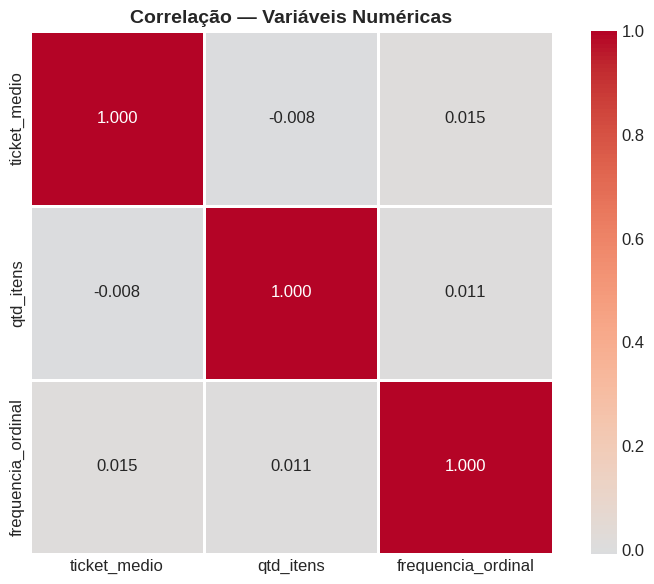

In [21]:
"""Matriz de correlação das variáveis numéricas."""

corr: pd.DataFrame = df_encoded[colunas_numericas].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    center=0, square=True, linewidths=1, ax=ax
)
ax.set_title('Correlação — Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Redução de Dimensionalidade

Utilizamos **PCA** (Análise de Componentes Principais) para:
- Visualizar os dados em 2D/3D
- Entender a variância explicada
- Verificar se há estrutura de clusters visível

**Nota**: PCA aqui é usado para *visualização*, não para reduzir features antes do clustering. O clustering é feito no espaço original.

Componentes para 80% da variância: 17
Componentes para 95% da variância: 24


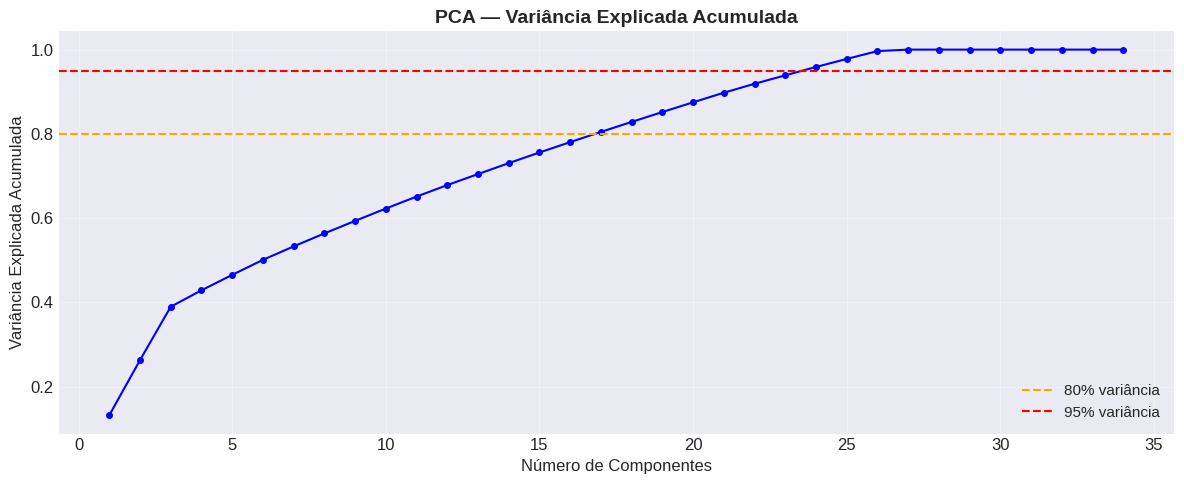

In [22]:
"""PCA — Análise de variância explicada.

Verificamos quantos componentes são necessários para explicar 80% e 95%
da variância total.
"""

pca_full: PCA = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

variancia_acumulada: np.ndarray = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, 'b-o', markersize=4)
ax.axhline(y=0.80, color='orange', linestyle='--', label='80% variância')
ax.axhline(y=0.95, color='red', linestyle='--', label='95% variância')
ax.set_xlabel('Número de Componentes', fontsize=12)
ax.set_ylabel('Variância Explicada Acumulada', fontsize=12)
ax.set_title('PCA — Variância Explicada Acumulada', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Encontrar componentes para 80% e 95%
n_80: int = np.argmax(variancia_acumulada >= 0.80) + 1
n_95: int = np.argmax(variancia_acumulada >= 0.95) + 1
print(f'Componentes para 80% da variância: {n_80}')
print(f'Componentes para 95% da variância: {n_95}')

plt.tight_layout()
plt.show()

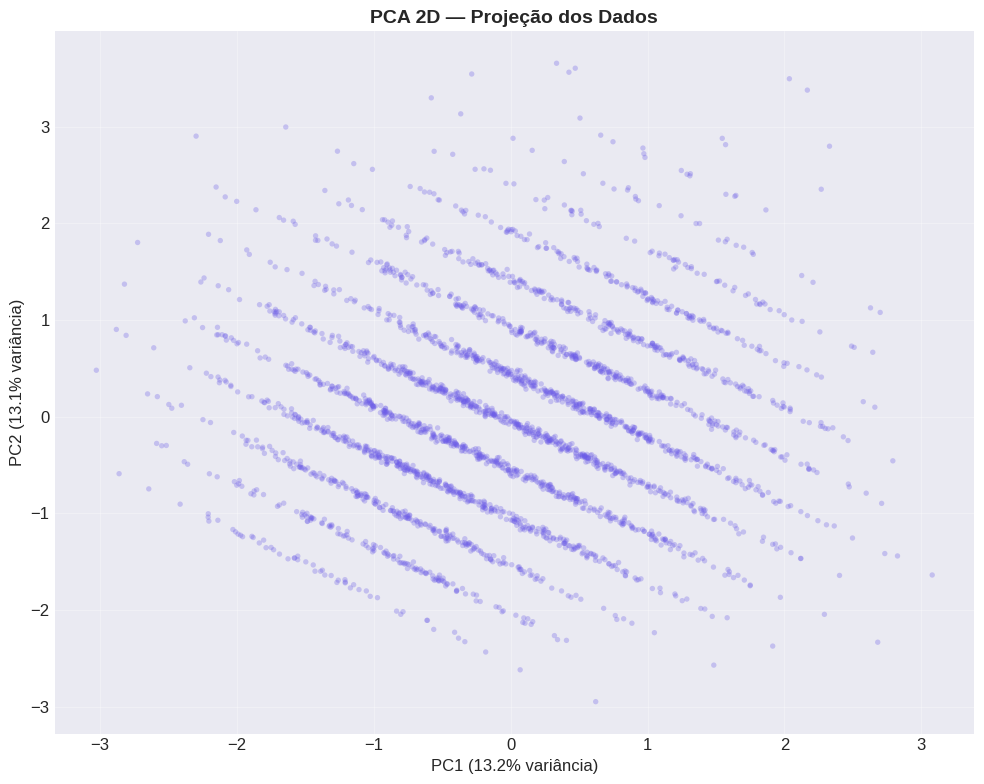

Variância explicada (2 componentes): 26.3%


In [23]:
"""PCA 2D — Visualização dos dados projetados."""

pca_2d: PCA = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2d: np.ndarray = pca_2d.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_pca2d[:, 0], X_pca2d[:, 1],
    alpha=0.3, s=15, c='#6c5ce7', edgecolors='none'
)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variância)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variância)', fontsize=12)
ax.set_title('PCA 2D — Projeção dos Dados', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Variância explicada (2 componentes): {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

---
## 6. Clustering

Utilizamos dois algoritmos:

1. **KMeans**: Baseline clássico para clustering. Assume clusters esféricos, otimiza inércia. Bom ponto de partida.
2. **GMM (Gaussian Mixture Models)**: Extensão probabilística do KMeans. Permite clusters elípticos e fornece probabilidades de pertencimento (soft clustering).

### Seleção do número de clusters
- **Método Elbow**: Buscar o "cotovelo" na curva de inércia
- **Silhouette Score**: Mede a separação entre clusters (-1 a 1, quanto maior melhor)

### Métricas de avaliação interna
- **Silhouette Score**: Separação entre clusters
- **Calinski-Harabasz**: Razão entre dispersão inter e intra-cluster (maior = melhor)
- **Davies-Bouldin**: Similaridade média entre clusters (menor = melhor)

In [24]:
"""Seleção do número de clusters — Elbow Method + Silhouette.

Testamos K de 2 a 10 para ambos os algoritmos.
"""

K_RANGE: range = range(2, 11)

# Resultados KMeans
inertias: list[float] = []
silhouettes_km: list[float] = []

# Resultados GMM
bics: list[float] = []
silhouettes_gmm: list[float] = []

print('Calculando métricas para K = 2..10...')

for k in K_RANGE:
    # --- KMeans ---
    km: KMeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels_km: np.ndarray = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes_km.append(silhouette_score(X, labels_km))

    # --- GMM ---
    gmm: GaussianMixture = GaussianMixture(
        n_components=k, random_state=RANDOM_STATE,
        covariance_type='full', n_init=3, max_iter=200
    )
    labels_gmm: np.ndarray = gmm.fit_predict(X)
    bics.append(gmm.bic(X))
    silhouettes_gmm.append(silhouette_score(X, labels_gmm))

    print(f'  K={k}: KMeans Sil={silhouettes_km[-1]:.4f} | GMM Sil={silhouettes_gmm[-1]:.4f}')

print('\n✅ Métricas calculadas.')

Calculando métricas para K = 2..10...
  K=2: KMeans Sil=0.0963 | GMM Sil=0.0299
  K=3: KMeans Sil=0.0852 | GMM Sil=0.0246
  K=4: KMeans Sil=0.0774 | GMM Sil=0.0286
  K=5: KMeans Sil=0.0655 | GMM Sil=0.0146
  K=6: KMeans Sil=0.0662 | GMM Sil=-0.0140
  K=7: KMeans Sil=0.0588 | GMM Sil=-0.0188
  K=8: KMeans Sil=0.0517 | GMM Sil=-0.0196
  K=9: KMeans Sil=0.0488 | GMM Sil=-0.0030
  K=10: KMeans Sil=0.0488 | GMM Sil=-0.0102

✅ Métricas calculadas.


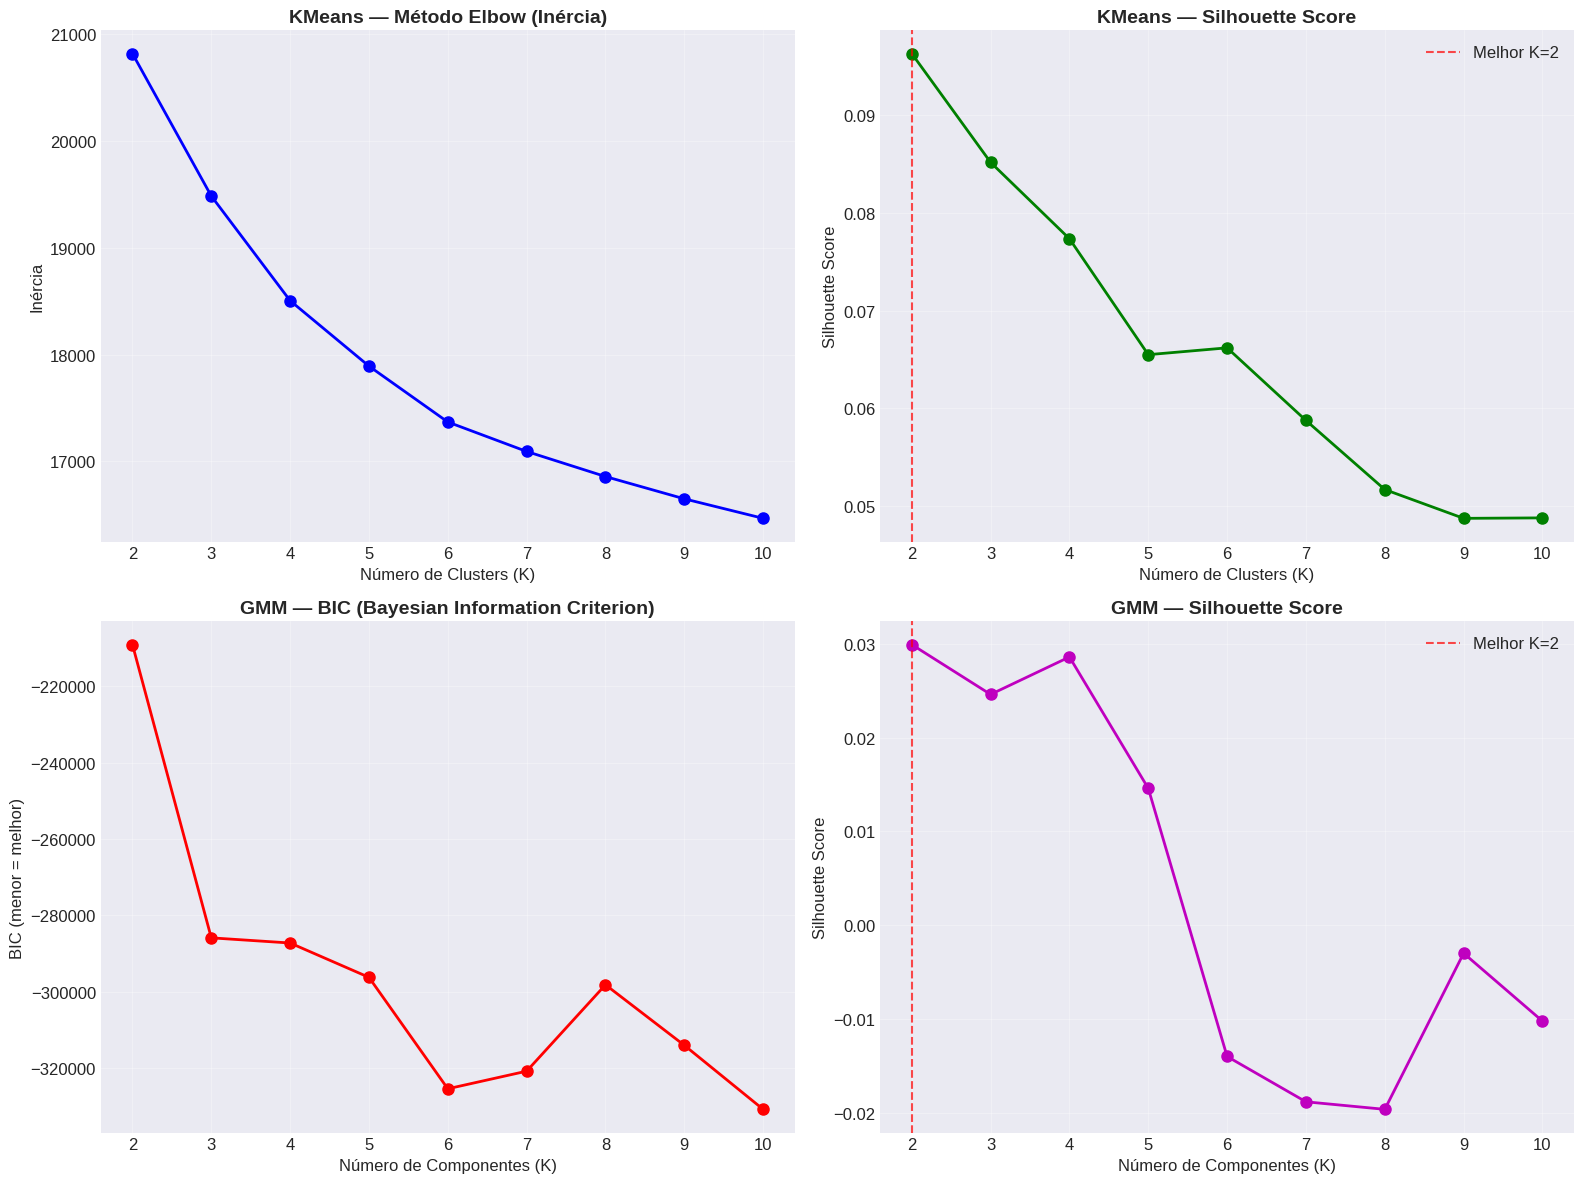


📌 Melhor K (Silhouette):
   KMeans: K=2 (Sil=0.0963)
   GMM:    K=2 (Sil=0.0299)


In [25]:
"""Visualizar Elbow + Silhouette para seleção de K."""

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Elbow — KMeans
axes[0][0].plot(list(K_RANGE), inertias, 'b-o', markersize=8, linewidth=2)
axes[0][0].set_title('KMeans — Método Elbow (Inércia)', fontsize=14, fontweight='bold')
axes[0][0].set_xlabel('Número de Clusters (K)')
axes[0][0].set_ylabel('Inércia')
axes[0][0].grid(True, alpha=0.3)

# 2. Silhouette — KMeans
axes[0][1].plot(list(K_RANGE), silhouettes_km, 'g-o', markersize=8, linewidth=2)
axes[0][1].set_title('KMeans — Silhouette Score', fontsize=14, fontweight='bold')
axes[0][1].set_xlabel('Número de Clusters (K)')
axes[0][1].set_ylabel('Silhouette Score')
axes[0][1].grid(True, alpha=0.3)

# Destacar melhor K
best_k_km: int = list(K_RANGE)[np.argmax(silhouettes_km)]
axes[0][1].axvline(x=best_k_km, color='red', linestyle='--', alpha=0.7,
                    label=f'Melhor K={best_k_km}')
axes[0][1].legend()

# 3. BIC — GMM
axes[1][0].plot(list(K_RANGE), bics, 'r-o', markersize=8, linewidth=2)
axes[1][0].set_title('GMM — BIC (Bayesian Information Criterion)', fontsize=14, fontweight='bold')
axes[1][0].set_xlabel('Número de Componentes (K)')
axes[1][0].set_ylabel('BIC (menor = melhor)')
axes[1][0].grid(True, alpha=0.3)

# 4. Silhouette — GMM
axes[1][1].plot(list(K_RANGE), silhouettes_gmm, 'm-o', markersize=8, linewidth=2)
axes[1][1].set_title('GMM — Silhouette Score', fontsize=14, fontweight='bold')
axes[1][1].set_xlabel('Número de Componentes (K)')
axes[1][1].set_ylabel('Silhouette Score')
axes[1][1].grid(True, alpha=0.3)

best_k_gmm: int = list(K_RANGE)[np.argmax(silhouettes_gmm)]
axes[1][1].axvline(x=best_k_gmm, color='red', linestyle='--', alpha=0.7,
                    label=f'Melhor K={best_k_gmm}')
axes[1][1].legend()

plt.tight_layout()
plt.show()

print(f'\n📌 Melhor K (Silhouette):')
print(f'   KMeans: K={best_k_km} (Sil={max(silhouettes_km):.4f})')
print(f'   GMM:    K={best_k_gmm} (Sil={max(silhouettes_gmm):.4f})')

In [26]:
"""Treinar modelos finais com o K selecionado.

Escolhemos o K que maximiza o Silhouette Score.
Se os dois algoritmos concordam no K, ótimo.
Se discordam, usamos o K do algoritmo com maior Silhouette.
"""

# Determinar K final
if silhouettes_km[best_k_km - 2] >= silhouettes_gmm[best_k_gmm - 2]:
    K_FINAL: int = best_k_km
    ALGORITMO_FINAL: str = 'KMeans'
    print(f'🏆 Algoritmo escolhido: KMeans com K={K_FINAL}')
else:
    K_FINAL = best_k_gmm
    ALGORITMO_FINAL = 'GMM'
    print(f'🏆 Algoritmo escolhido: GMM com K={K_FINAL}')

# Treinar KMeans final
km_final: KMeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20, max_iter=500)
labels_km_final: np.ndarray = km_final.fit_predict(X)

# Treinar GMM final
gmm_final: GaussianMixture = GaussianMixture(
    n_components=K_FINAL, random_state=RANDOM_STATE,
    covariance_type='full', n_init=5, max_iter=300
)
labels_gmm_final: np.ndarray = gmm_final.fit_predict(X)

print(f'\n--- Resultados com K={K_FINAL} ---')
print(f'KMeans — Silhouette: {silhouette_score(X, labels_km_final):.4f}')
print(f'GMM    — Silhouette: {silhouette_score(X, labels_gmm_final):.4f}')

🏆 Algoritmo escolhido: KMeans com K=2

--- Resultados com K=2 ---
KMeans — Silhouette: 0.0963
GMM    — Silhouette: 0.0299


In [27]:
"""Comparação detalhada entre KMeans e GMM.

Métricas internas:
- Silhouette Score: [-1, 1], maior = clusters mais separados
- Calinski-Harabasz Index: >0, maior = clusters mais densos e separados
- Davies-Bouldin Index: >0, menor = clusters mais distintos
"""

metricas: dict[str, dict[str, float]] = {
    'KMeans': {
        'Silhouette': silhouette_score(X, labels_km_final),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels_km_final),
        'Davies-Bouldin': davies_bouldin_score(X, labels_km_final)
    },
    'GMM': {
        'Silhouette': silhouette_score(X, labels_gmm_final),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels_gmm_final),
        'Davies-Bouldin': davies_bouldin_score(X, labels_gmm_final)
    }
}

df_metricas: pd.DataFrame = pd.DataFrame(metricas).T
df_metricas['Silhouette'] = df_metricas['Silhouette'].round(4)
df_metricas['Calinski-Harabasz'] = df_metricas['Calinski-Harabasz'].round(2)
df_metricas['Davies-Bouldin'] = df_metricas['Davies-Bouldin'].round(4)

print('=== COMPARAÇÃO DE ALGORITMOS ===')
print(f'Número de clusters: K = {K_FINAL}')
print()
print(df_metricas.to_markdown())
print()
print('📝 Silhouette: maior = melhor')
print('📝 Calinski-Harabasz: maior = melhor')
print('📝 Davies-Bouldin: menor = melhor')

=== COMPARAÇÃO DE ALGORITMOS ===
Número de clusters: K = 2

|        |   Silhouette |   Calinski-Harabasz |   Davies-Bouldin |
|:-------|-------------:|--------------------:|-----------------:|
| KMeans |       0.0963 |              334.71 |           2.9279 |
| GMM    |       0.0299 |               55.57 |           5.1449 |

📝 Silhouette: maior = melhor
📝 Calinski-Harabasz: maior = melhor
📝 Davies-Bouldin: menor = melhor


In [28]:
"""Escolher labels finais baseado na comparação."""

# Usar o algoritmo com melhor Silhouette Score
if metricas['KMeans']['Silhouette'] >= metricas['GMM']['Silhouette']:
    labels_final: np.ndarray = labels_km_final
    algo_escolhido: str = 'KMeans'
else:
    labels_final = labels_gmm_final
    algo_escolhido = 'GMM'

print(f'\n🏆 Algoritmo final selecionado: {algo_escolhido}')
print(f'\nDistribuição dos clusters:')
cluster_counts: pd.Series = pd.Series(labels_final).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f'  Cluster {cluster_id}: {count} consumidores ({count/len(labels_final)*100:.1f}%)')


🏆 Algoritmo final selecionado: KMeans

Distribuição dos clusters:
  Cluster 0: 1273 consumidores (42.4%)
  Cluster 1: 1727 consumidores (57.6%)


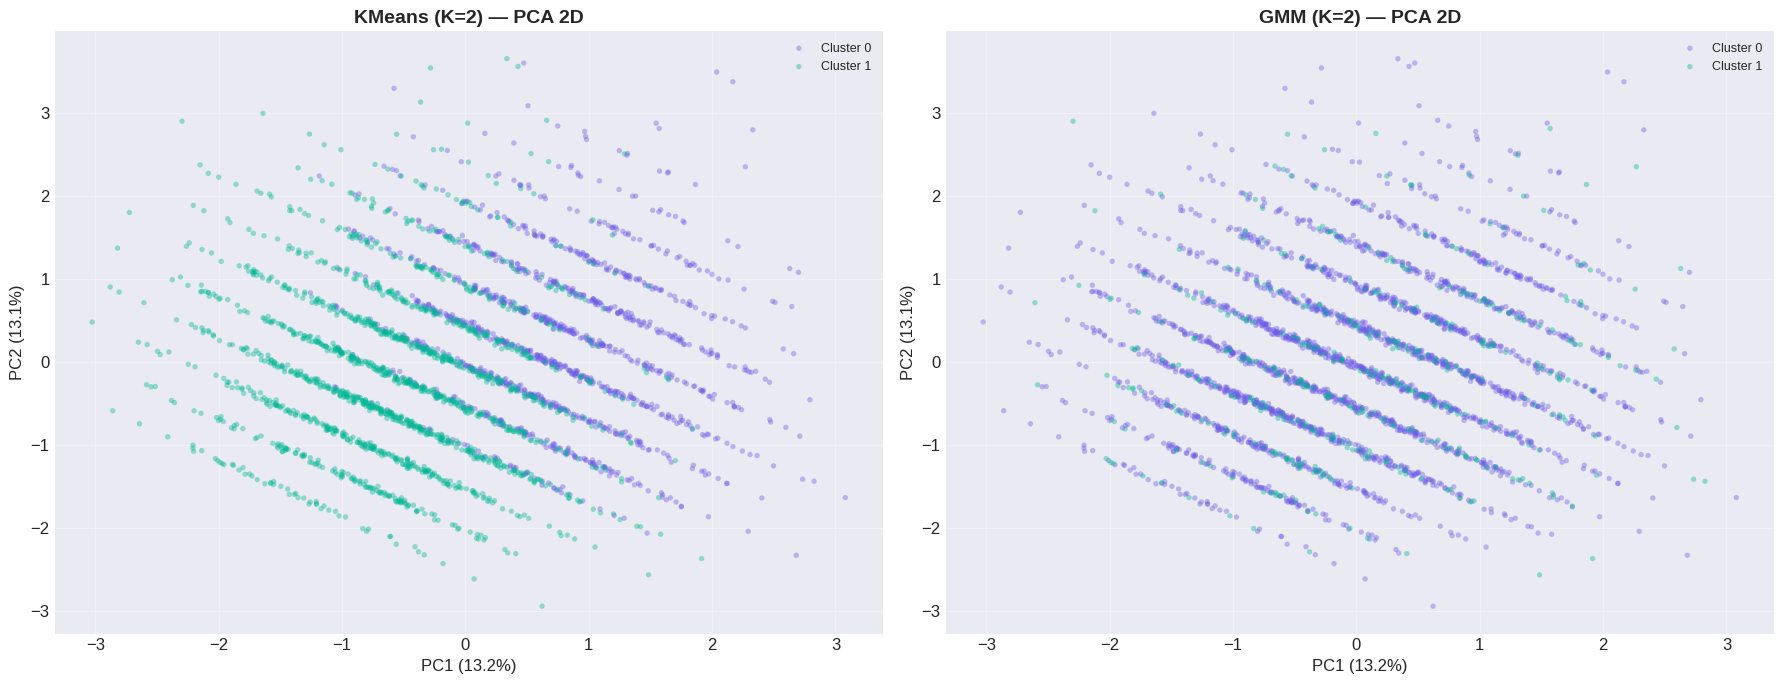

In [29]:
"""Visualizar clusters no espaço PCA 2D."""

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
cores_clusters: list[str] = ['#6c5ce7', '#00b894', '#e17055', '#0984e3', '#fdcb6e',
                              '#d63031', '#00cec9', '#e84393', '#2d3436', '#636e72']

# KMeans
for i in range(K_FINAL):
    mask: np.ndarray = labels_km_final == i
    axes[0].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
                    c=cores_clusters[i], label=f'Cluster {i}',
                    alpha=0.4, s=15, edgecolors='none')
axes[0].set_title(f'KMeans (K={K_FINAL}) — PCA 2D', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# GMM
for i in range(K_FINAL):
    mask = labels_gmm_final == i
    axes[1].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1],
                    c=cores_clusters[i], label=f'Cluster {i}',
                    alpha=0.4, s=15, edgecolors='none')
axes[1].set_title(f'GMM (K={K_FINAL}) — PCA 2D', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Perfilamento dos Clusters

Para cada cluster, identificamos:
- **Tamanho** (quantidade de consumidores)
- **Valores médios** das variáveis numéricas
- **Valores modais** (mais frequentes) das variáveis categóricas
- **Diferenças significativas** entre clusters

In [30]:
"""Adicionar labels dos clusters ao dataframe original."""

df['cluster'] = labels_final

# Adicionar idade ao df original
df['data_nascimento_dt'] = pd.to_datetime(df['data_nascimento'], format='%d/%m/%Y', errors='coerce')
df['idade'] = ((datetime(2026, 5, 25) - df['data_nascimento_dt']).dt.days / 365.25).astype(int)

# Faixa etária
df['faixa_etaria'] = pd.cut(
    df['idade'],
    bins=[0, 18, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 120],
    labels=['<18', '18-20', '20-25', '25-30', '30-35', '35-40',
            '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70+'],
    right=False
)

print(f'✅ Coluna cluster adicionada ao dataset original.')
print(f'Clusters: {sorted(df["cluster"].unique())}')

✅ Coluna cluster adicionada ao dataset original.
Clusters: [np.int32(0), np.int32(1)]


In [31]:
"""Tabela resumo por cluster.

Para cada cluster:
- Tamanho (n, %)
- Médias numéricas: ticket_medio, qtd_itens, idade
- Modas categóricas: canal, categoria, regiao, frequencia, pagamento, genero
"""

colunas_modais: list[str] = [
    'canal_preferido', 'categoria_favorita', 'regiao',
    'frequencia_compra', 'pagamento', 'genero', 'faixa_etaria'
]

colunas_medias: list[str] = ['ticket_medio', 'qtd_itens', 'idade']

resumo: list[dict] = []

for cluster_id in sorted(df['cluster'].unique()):
    grupo: pd.DataFrame = df[df['cluster'] == cluster_id]
    perfil: dict = {
        'cluster': cluster_id,
        'tamanho': len(grupo),
        'percentual': f'{len(grupo)/len(df)*100:.1f}%'
    }

    # Médias numéricas
    for col in colunas_medias:
        perfil[f'{col}_media'] = round(grupo[col].mean(), 2)
        perfil[f'{col}_mediana'] = round(grupo[col].median(), 2)

    # Modas categóricas
    for col in colunas_modais:
        moda: str = grupo[col].mode().iloc[0] if not grupo[col].mode().empty else 'N/A'
        pct_moda: float = (grupo[col] == moda).sum() / len(grupo) * 100
        perfil[f'{col}_moda'] = moda
        perfil[f'{col}_pct_moda'] = f'{pct_moda:.1f}%'

    resumo.append(perfil)

df_resumo: pd.DataFrame = pd.DataFrame(resumo)

print('=== PERFIL RESUMIDO POR CLUSTER ===')
print()

for _, row in df_resumo.iterrows():
    print(f'\n--- Cluster {row["cluster"]} ({row["tamanho"]} consumidores, {row["percentual"]}) ---')
    print(f'  Ticket médio: R$ {row["ticket_medio_media"]} (mediana: R$ {row["ticket_medio_mediana"]})')
    print(f'  Qtd itens: {row["qtd_itens_media"]} (mediana: {row["qtd_itens_mediana"]})')
    print(f'  Idade média: {row["idade_media"]} anos (mediana: {row["idade_mediana"]})')
    print(f'  Faixa etária principal: {row["faixa_etaria_moda"]} ({row["faixa_etaria_pct_moda"]})')
    print(f'  Canal preferido: {row["canal_preferido_moda"]} ({row["canal_preferido_pct_moda"]})')
    print(f'  Categoria favorita: {row["categoria_favorita_moda"]} ({row["categoria_favorita_pct_moda"]})')
    print(f'  Região: {row["regiao_moda"]} ({row["regiao_pct_moda"]})')
    print(f'  Frequência compra: {row["frequencia_compra_moda"]} ({row["frequencia_compra_pct_moda"]})')
    print(f'  Pagamento: {row["pagamento_moda"]} ({row["pagamento_pct_moda"]})')
    print(f'  Gênero predominante: {row["genero_moda"]} ({row["genero_pct_moda"]})')

=== PERFIL RESUMIDO POR CLUSTER ===


--- Cluster 0 (1273 consumidores, 42.4%) ---
  Ticket médio: R$ 122.07 (mediana: R$ 122.87)
  Qtd itens: 4.07 (mediana: 4.0)
  Idade média: 44.1 anos (mediana: 44.0)
  Faixa etária principal: 30-35 (10.7%)
  Canal preferido: loja_fisica (25.1%)
  Categoria favorita: bebidas (20.7%)
  Região: sudeste (24.0%)
  Frequência compra: semanal (56.5%)
  Pagamento: credito (22.0%)
  Gênero predominante: masculino (27.1%)

--- Cluster 1 (1727 consumidores, 57.6%) ---
  Ticket médio: R$ 121.63 (mediana: R$ 121.82)
  Qtd itens: 4.03 (mediana: 4.0)
  Idade média: 45.04 anos (mediana: 45.0)
  Faixa etária principal: 65-70 (11.9%)
  Canal preferido: loja_fisica (23.8%)
  Categoria favorita: bebidas (20.9%)
  Região: sudeste (22.9%)
  Frequência compra: trimestral (34.5%)
  Pagamento: credito (24.3%)
  Gênero predominante: masculino (30.6%)


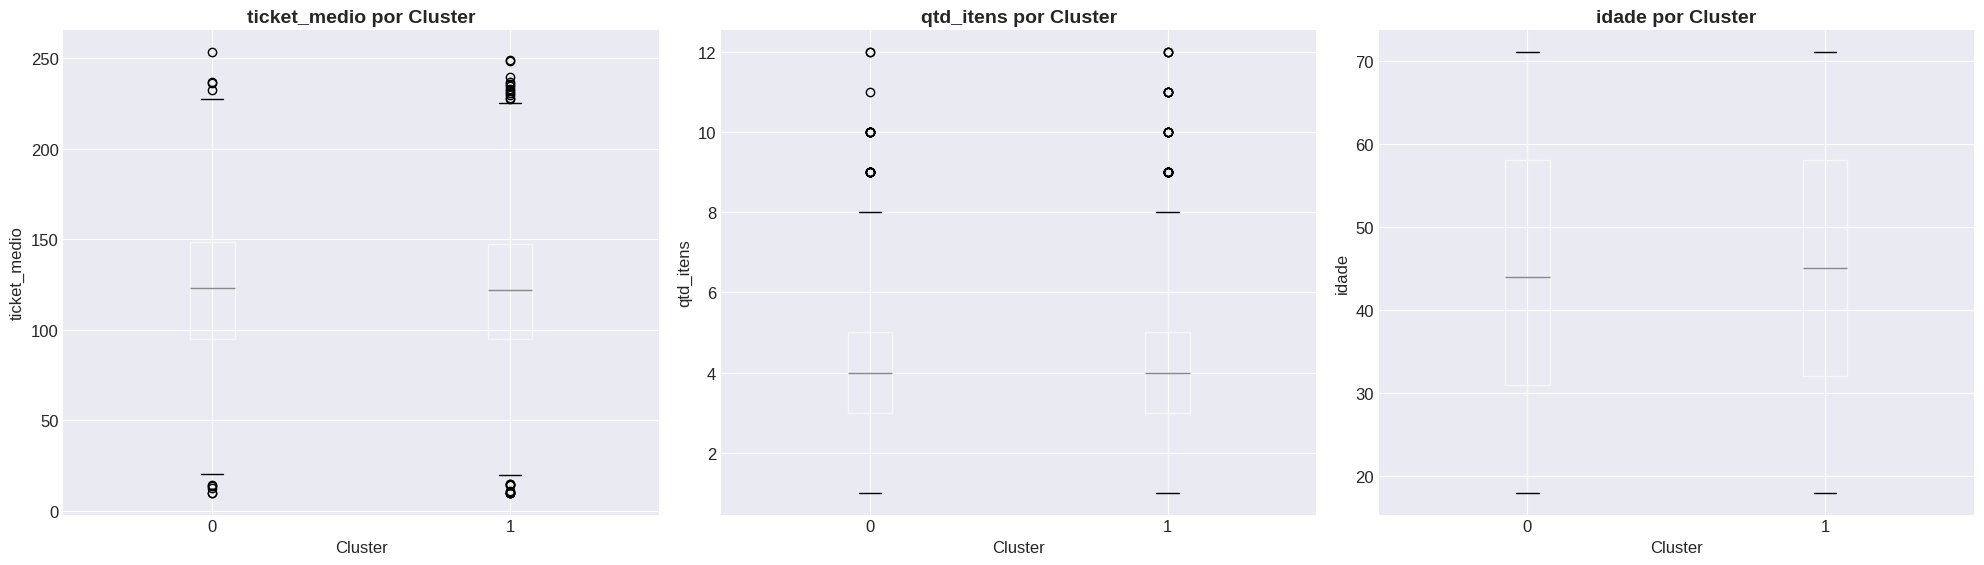

In [32]:
"""Visualizar diferenças entre clusters — variáveis numéricas."""

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, col in enumerate(colunas_medias):
    df.boxplot(column=col, by='cluster', ax=axes[idx])
    axes[idx].set_title(f'{col} por Cluster', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

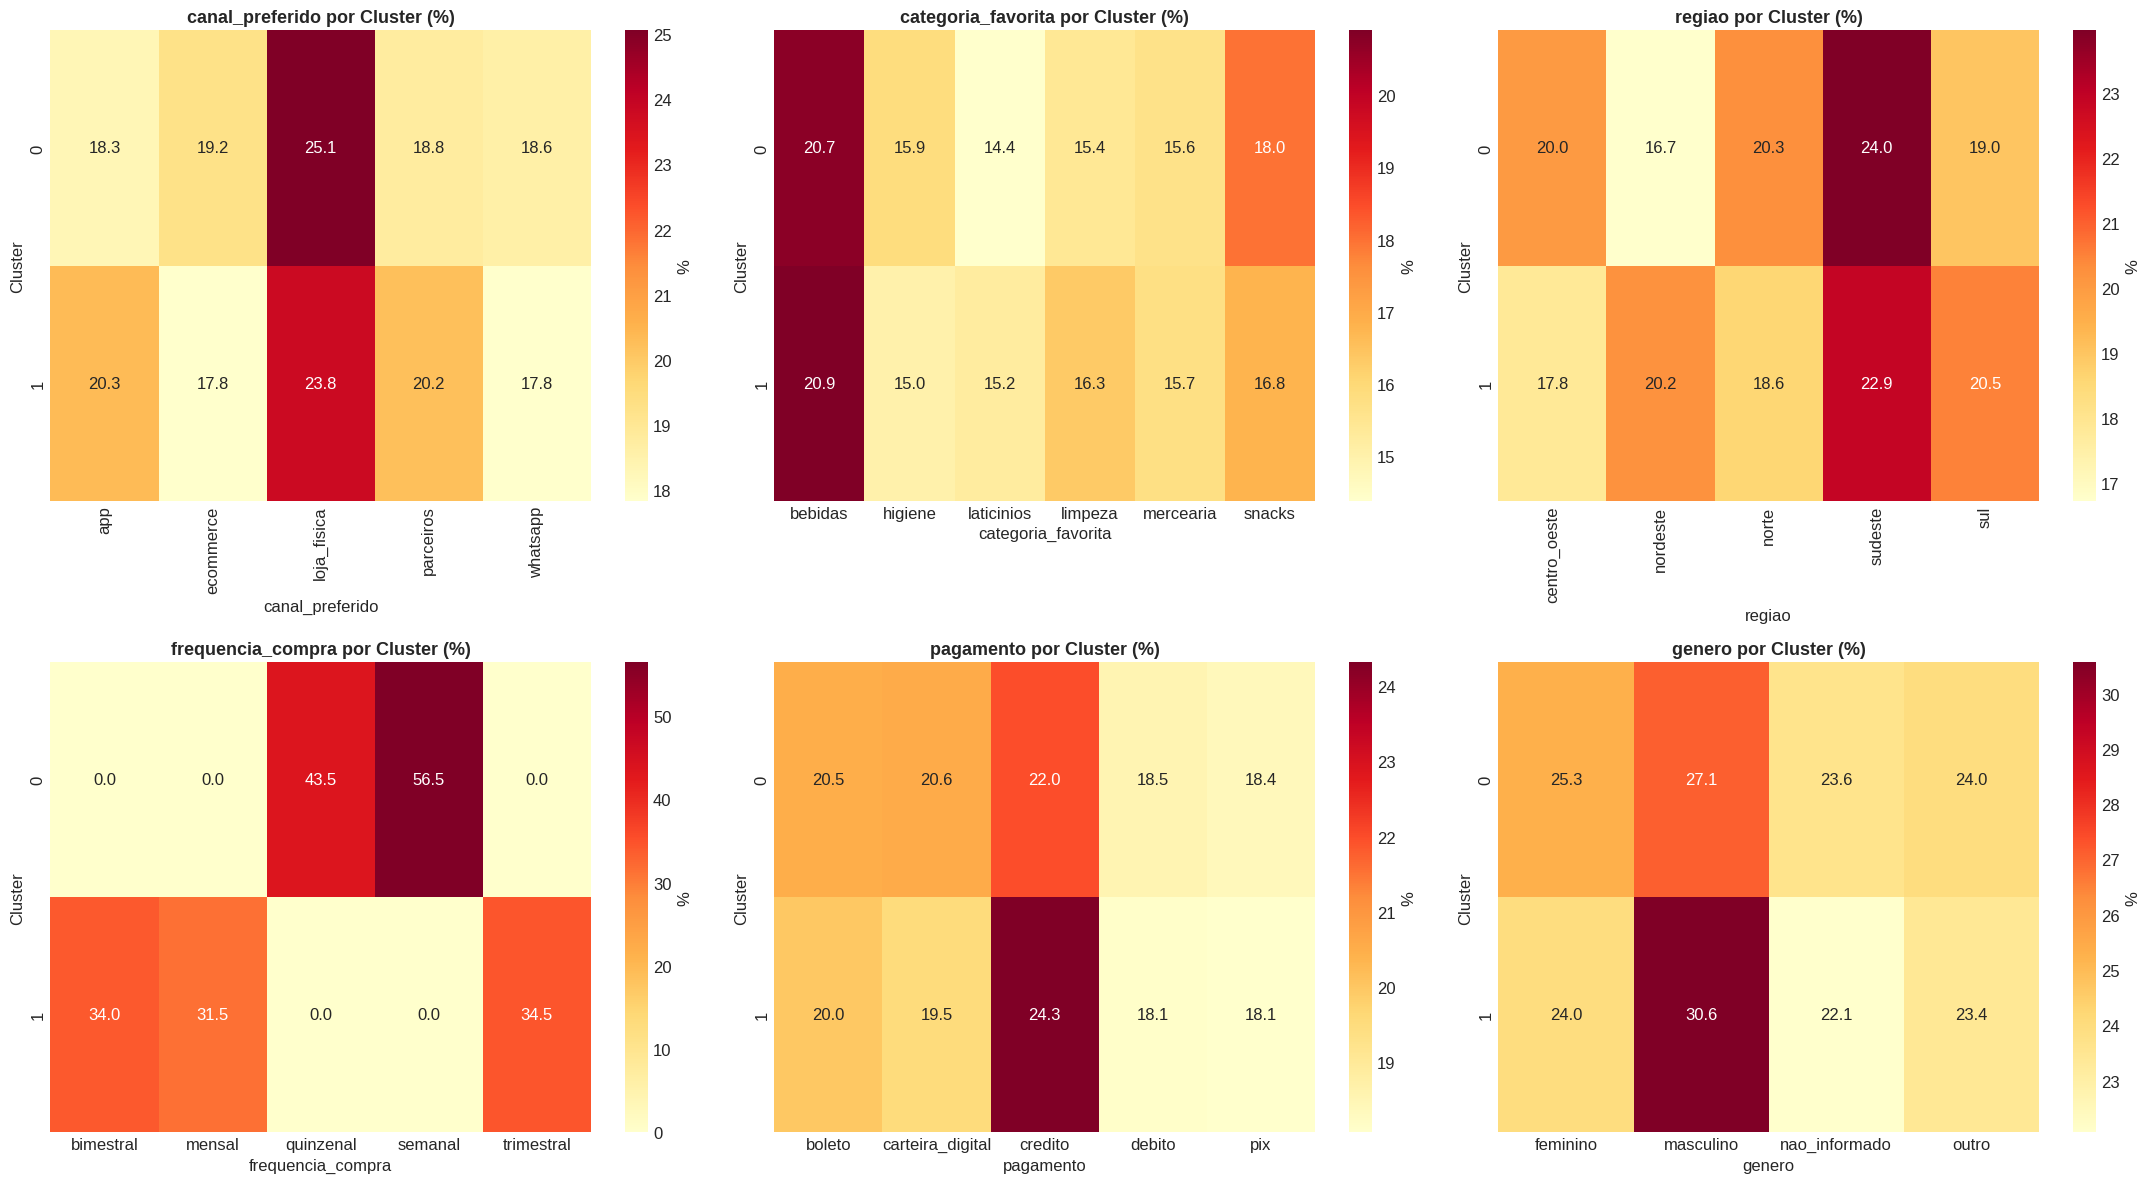

In [33]:
"""Visualizar diferenças entre clusters — variáveis categóricas.

Heatmap de proporções para cada variável categórica por cluster.
"""

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
categoricas_viz: list[str] = [
    'canal_preferido', 'categoria_favorita', 'regiao',
    'frequencia_compra', 'pagamento', 'genero'
]

for idx, col in enumerate(categoricas_viz):
    ax = axes[idx // 3][idx % 3]

    # Tabela de proporções (% dentro de cada cluster)
    cross: pd.DataFrame = pd.crosstab(
        df['cluster'], df[col], normalize='index'
    ) * 100

    sns.heatmap(
        cross, annot=True, fmt='.1f', cmap='YlOrRd',
        ax=ax, cbar_kws={'label': '%'}
    )
    ax.set_title(f'{col} por Cluster (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Cluster')

plt.tight_layout()
plt.show()

In [34]:
"""Teste estatístico: diferenças significativas entre clusters.

- ANOVA (one-way) para variáveis numéricas
- Chi-quadrado para variáveis categóricas
"""

from scipy import stats

print('=== TESTES ESTATÍSTICOS ===')
print()

# ANOVA para numéricas
print('--- ANOVA (Numéricas) ---')
for col in colunas_medias:
    grupos_anova: list[np.ndarray] = [
        df[df['cluster'] == c][col].values for c in sorted(df['cluster'].unique())
    ]
    f_stat, p_value = stats.f_oneway(*grupos_anova)
    significativo: str = '✅ Significativo' if p_value < 0.05 else '❌ Não significativo'
    print(f'  {col}: F={f_stat:.2f}, p={p_value:.6f} → {significativo}')

print()

# Chi-quadrado para categóricas
print('--- Chi-Quadrado (Categóricas) ---')
for col in categoricas_viz:
    tabela: pd.DataFrame = pd.crosstab(df['cluster'], df[col])
    chi2, p_value, dof, expected = stats.chi2_contingency(tabela)
    significativo = '✅ Significativo' if p_value < 0.05 else '❌ Não significativo'
    print(f'  {col}: χ²={chi2:.2f}, p={p_value:.6f} → {significativo}')

=== TESTES ESTATÍSTICOS ===

--- ANOVA (Numéricas) ---
  ticket_medio: F=0.09, p=0.767834 → ❌ Não significativo
  qtd_itens: F=0.25, p=0.615393 → ❌ Não significativo
  idade: F=2.74, p=0.097879 → ❌ Não significativo

--- Chi-Quadrado (Categóricas) ---
  canal_preferido: χ²=3.82, p=0.430317 → ❌ Não significativo
  categoria_favorita: χ²=1.74, p=0.883430 → ❌ Não significativo
  regiao: χ²=8.87, p=0.064392 → ❌ Não significativo
  frequencia_compra: χ²=3000.00, p=0.000000 → ✅ Significativo
  pagamento: χ²=2.32, p=0.676292 → ❌ Não significativo
  genero: χ²=4.47, p=0.215377 → ❌ Não significativo


---
## 8. Exportação — Perfil dos Clusters para o Sistema de Agentes

Exportamos `cluster_profiles.json` contendo o perfil completo de cada cluster,
para ser consumido pelo `persona_builder.py` na Parte 2 (Camada Agentic).

In [35]:
"""Construir e exportar perfis dos clusters em JSON.

Cada cluster terá:
- id, tamanho, percentual
- Médias numéricas (ticket_medio, qtd_itens, idade)
- Distribuição completa das categóricas (top valores + %)
- Moda de cada categórica
"""

profiles: list[dict] = []

for cluster_id in sorted(df['cluster'].unique()):
    grupo: pd.DataFrame = df[df['cluster'] == cluster_id]

    perfil: dict = {
        'cluster_id': int(cluster_id),
        'tamanho': int(len(grupo)),
        'percentual': round(len(grupo) / len(df) * 100, 1),

        # Numéricas
        'numericas': {
            'ticket_medio': {
                'media': round(float(grupo['ticket_medio'].mean()), 2),
                'mediana': round(float(grupo['ticket_medio'].median()), 2),
                'std': round(float(grupo['ticket_medio'].std()), 2),
                'min': round(float(grupo['ticket_medio'].min()), 2),
                'max': round(float(grupo['ticket_medio'].max()), 2)
            },
            'qtd_itens': {
                'media': round(float(grupo['qtd_itens'].mean()), 2),
                'mediana': round(float(grupo['qtd_itens'].median()), 2),
                'std': round(float(grupo['qtd_itens'].std()), 2),
                'min': int(grupo['qtd_itens'].min()),
                'max': int(grupo['qtd_itens'].max())
            },
            'idade': {
                'media': round(float(grupo['idade'].mean()), 1),
                'mediana': round(float(grupo['idade'].median()), 1),
                'std': round(float(grupo['idade'].std()), 1),
                'min': int(grupo['idade'].min()),
                'max': int(grupo['idade'].max())
            }
        },

        # Categóricas — distribuição completa
        'categoricas': {}
    }

    for col in categoricas_viz + ['faixa_etaria']:
        dist: pd.Series = grupo[col].value_counts(normalize=True).round(4)
        perfil['categoricas'][col] = {
            'moda': str(dist.index[0]),
            'moda_pct': round(float(dist.iloc[0]) * 100, 1),
            'distribuicao': {
                str(k): round(float(v) * 100, 1) for k, v in dist.items()
            }
        }

    profiles.append(perfil)

# Metadados
output: dict = {
    'metadata': {
        'algoritmo': algo_escolhido,
        'n_clusters': K_FINAL,
        'silhouette_score': round(float(silhouette_score(X, labels_final)), 4),
        'calinski_harabasz': round(float(calinski_harabasz_score(X, labels_final)), 2),
        'davies_bouldin': round(float(davies_bouldin_score(X, labels_final)), 4),
        'total_amostras': int(len(df)),
        'data_geracao': datetime.now().isoformat()
    },
    'clusters': profiles
}

# Salvar JSON
output_path: str = '../data/cluster_profiles.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f'✅ Perfis exportados para: {output_path}')
print(f'   {K_FINAL} clusters, {len(df)} amostras')
print(f'   Algoritmo: {algo_escolhido}')
print(f'   Silhouette: {silhouette_score(X, labels_final):.4f}')

FileNotFoundError: [Errno 2] No such file or directory: '../data/cluster_profiles.json'

In [ ]:
"""Visualização final: resumo visual dos clusters."""

print('='*60)
print('  🌌 GALAXIES — RESUMO FINAL DO CLUSTERING')
print('='*60)
print(f'\n  Algoritmo: {algo_escolhido}')
print(f'  Clusters: {K_FINAL}')
print(f'  Silhouette Score: {silhouette_score(X, labels_final):.4f}')
print(f'  Total de consumidores: {len(df)}')
print(f'\n  Perfis exportados para: {output_path}')
print(f'  Próximo passo: engine/persona_builder.py')
print('='*60)